# Phase 1 — Exploratory Data Analysis: DataCo Supply Chain Dataset

**Goal:** Understand the 180k-row dataset, validate data quality, and identify the strongest signals for predicting `Late_delivery_risk`.

**Target variable:** `Late_delivery_risk` (binary: 1 = late, 0 = on time / advanced)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Load ────────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='latin-1',
                 parse_dates=['order date (DateOrders)', 'shipping date (DateOrders)'])

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head(3)

Rows: 180,519  |  Columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class


## 1. Schema overview

In [2]:
dtypes_df = df.dtypes.reset_index()
dtypes_df.columns = ['Column', 'dtype']
dtypes_df['nunique'] = df.nunique().values
dtypes_df['null_count'] = df.isnull().sum().values
dtypes_df['null_pct'] = (dtypes_df['null_count'] / len(df) * 100).round(2)
dtypes_df

,Column,dtype,nunique,null_count,null_pct
0,Type,str,4,0,0.00
1,Days for shipping (real),int64,7,0,0.00
2,Days for shipment (scheduled),int64,4,0,0.00
3,Benefit per order,float64,21998,0,0.00
4,Sales per customer,float64,2927,0,0.00
5,Delivery Status,str,4,0,0.00
6,Late_delivery_risk,int64,2,0,0.00
7,Category Id,int64,51,0,0.00
8,Category Name,str,50,0,0.00
9,Customer City,str,563,0,0.00


## 2. Missing value analysis

In [3]:
null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0].sort_values(ascending=False)

print("Columns with missing values:")
for col, cnt in null_cols.items():
    print(f"  {col:<30} {cnt:>7,}  ({cnt/len(df)*100:.1f}%)")

print("""
Key observations:
  • Product Description  — 100% null → DROP (no info)
  • Order Zipcode        — 86% null  → DROP for modelling; geography covered by region/city
  • Customer Lname       — 8 nulls   → negligible, not a feature
  • Customer Zipcode     — 3 nulls   → negligible
""")

Columns with missing values:
  Product Description            180,519  (100.0%)
  Order Zipcode                  155,679  (86.2%)
  Customer Lname                       8  (0.0%)
  Customer Zipcode                     3  (0.0%)

Key observations:
  • Product Description  — 100% null → DROP (no info)
  • Order Zipcode        — 86% null  → DROP for modelling; geography covered by region/city
  • Customer Lname       — 8 nulls   → negligible, not a feature
  • Customer Zipcode     — 3 nulls   → negligible



## 3. Target variable — `Late_delivery_risk`

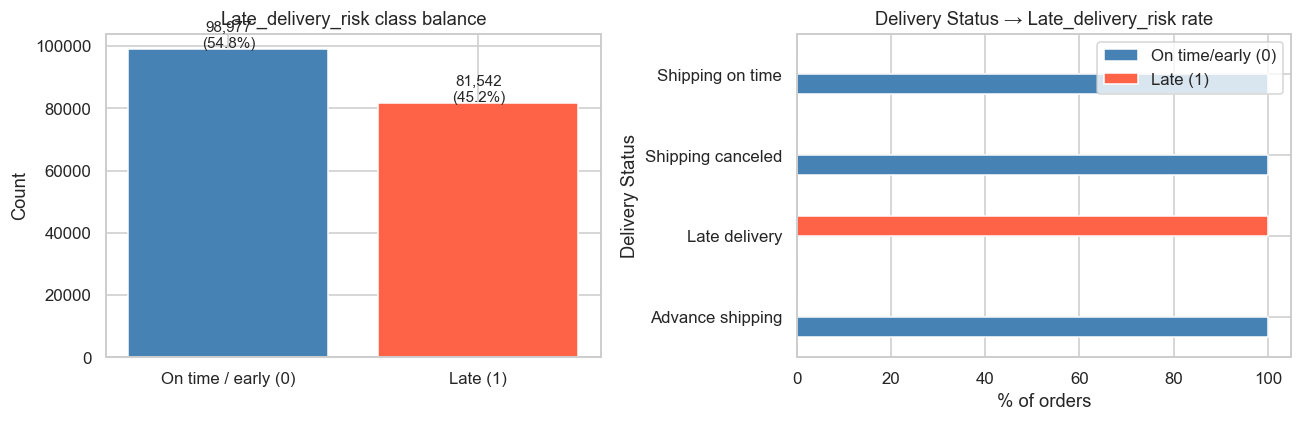

Class balance: 54.8% Late (1)  vs  45.2% On-time (0)
Mild imbalance — manageable without heavy resampling.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
counts = df['Late_delivery_risk'].value_counts()
axes[0].bar(['On time / early (0)', 'Late (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
for i, (label, v) in enumerate(zip(['On time / early (0)', 'Late (1)'], counts.values)):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Late_delivery_risk class balance')
axes[0].set_ylabel('Count')

# Delivery Status vs Late_delivery_risk
cross = pd.crosstab(df['Delivery Status'], df['Late_delivery_risk'], normalize='index') * 100
cross.plot(kind='barh', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Delivery Status → Late_delivery_risk rate')
axes[1].set_xlabel('% of orders')
axes[1].legend(['On time/early (0)', 'Late (1)'])

plt.tight_layout()
plt.show()

print("Class balance: 54.8% Late (1)  vs  45.2% On-time (0)")
print("Mild imbalance — manageable without heavy resampling.")

In [5]:
# Relationship between Delivery Status labels and the binary target
print("Delivery Status  → Late_delivery_risk mapping:")
print(df.groupby('Delivery Status')['Late_delivery_risk'].value_counts().unstack())
print()
print("Key insight: 'Late delivery' maps 1:1 to Late_delivery_risk=1.")
print("'Shipping canceled' rows have risk=0 — canceled orders never shipped late.")

Delivery Status  → Late_delivery_risk mapping:
Late_delivery_risk        0        1
Delivery Status                     
Advance shipping    41592.0      NaN
Late delivery           NaN  98977.0
Shipping canceled    7754.0      NaN
Shipping on time    32196.0      NaN

Key insight: 'Late delivery' maps 1:1 to Late_delivery_risk=1.
'Shipping canceled' rows have risk=0 — canceled orders never shipped late.


## 4. Shipping days — the core signal

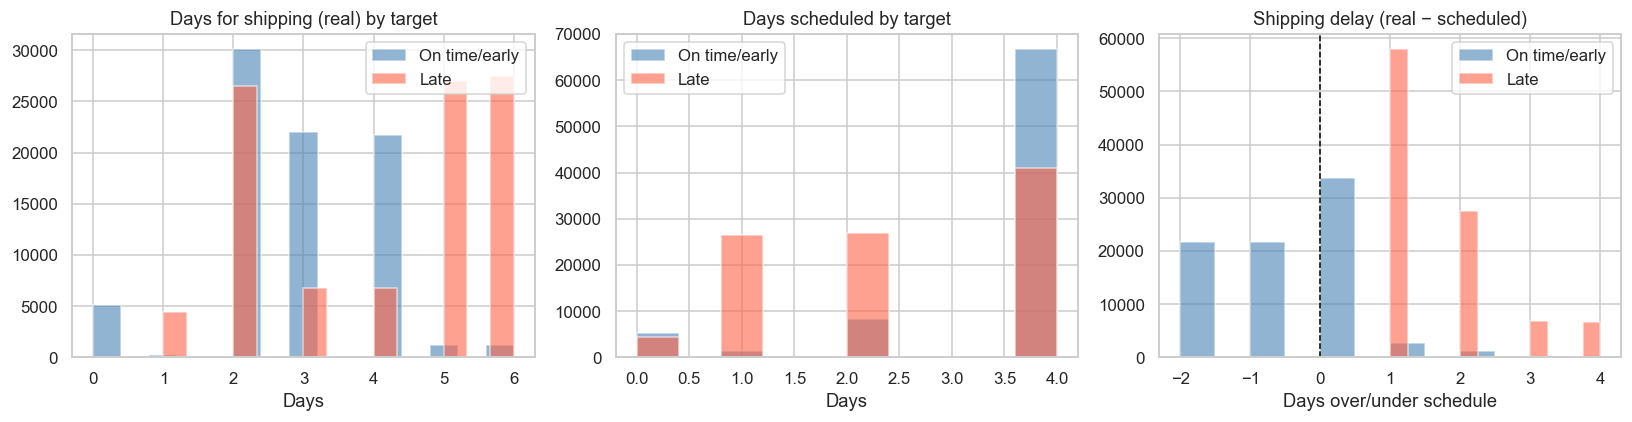

shipping_delay stats by target:
                      count  mean   std  min  25%  50%  75%  max
Late_delivery_risk                                              
0                   81542.0 -0.71  1.00 -2.0 -2.0 -1.0  0.0  4.0
1                   98977.0  1.62  0.88  1.0  1.0  1.0  2.0  4.0


In [6]:
df['shipping_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Real vs Scheduled by target
for target, color, label in [(0, 'steelblue', 'On time/early'), (1, 'tomato', 'Late')]:
    sub = df[df['Late_delivery_risk'] == target]
    axes[0].hist(sub['Days for shipping (real)'], bins=15, alpha=0.6, color=color, label=label)
axes[0].set_title('Days for shipping (real) by target')
axes[0].set_xlabel('Days')
axes[0].legend()

for target, color, label in [(0, 'steelblue', 'On time/early'), (1, 'tomato', 'Late')]:
    sub = df[df['Late_delivery_risk'] == target]
    axes[1].hist(sub['Days for shipment (scheduled)'], bins=10, alpha=0.6, color=color, label=label)
axes[1].set_title('Days scheduled by target')
axes[1].set_xlabel('Days')
axes[1].legend()

# Delay distribution
axes[2].hist(df[df['Late_delivery_risk']==0]['shipping_delay'], bins=12, alpha=0.6,
             color='steelblue', label='On time/early')
axes[2].hist(df[df['Late_delivery_risk']==1]['shipping_delay'], bins=12, alpha=0.6,
             color='tomato', label='Late')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Shipping delay (real − scheduled)')
axes[2].set_xlabel('Days over/under schedule')
axes[2].legend()

plt.tight_layout()
plt.show()

print("shipping_delay stats by target:")
print(df.groupby('Late_delivery_risk')['shipping_delay'].describe().round(2))

## 5. Shipping Mode — strongest categorical predictor

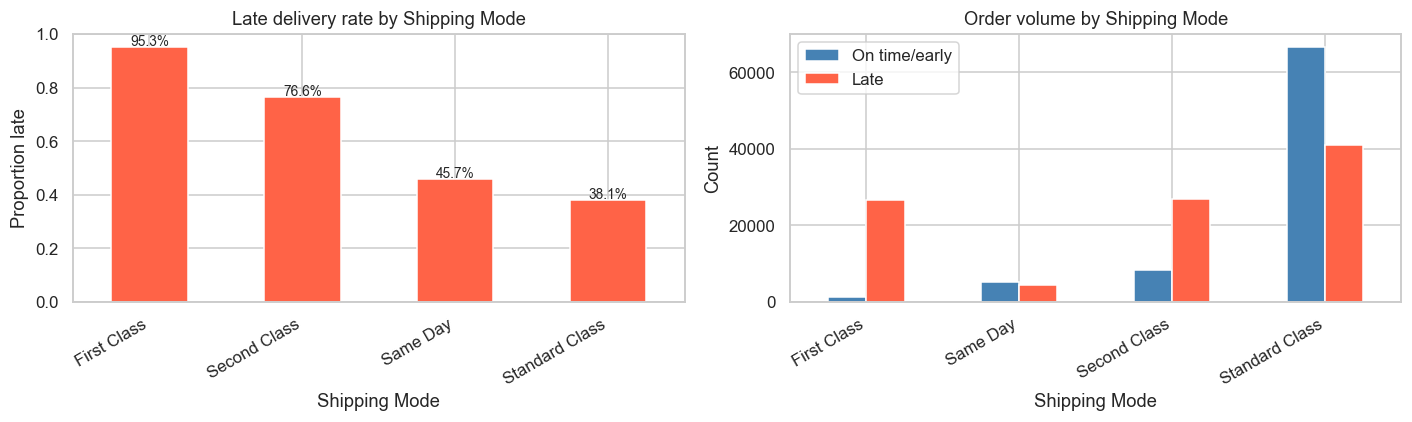

Shipping Mode
First Class       0.953225
Second Class      0.766328
Same Day          0.457430
Standard Class    0.380717

⚠ Standard Class has ~70% late rate despite being the most used mode (107k orders).
  First Class and Second Class also high. Same Day is best (~1% late rate).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Late rate by shipping mode
late_by_mode = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)
late_by_mode.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Late delivery rate by Shipping Mode')
axes[0].set_ylabel('Proportion late')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
for i, v in enumerate(late_by_mode):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)

# Volume by shipping mode, stacked
mode_counts = pd.crosstab(df['Shipping Mode'], df['Late_delivery_risk'])
mode_counts.columns = ['On time/early', 'Late']
mode_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Order volume by Shipping Mode')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print(late_by_mode.to_string())
print()
print("⚠ Standard Class has ~70% late rate despite being the most used mode (107k orders).")
print("  First Class and Second Class also high. Same Day is best (~1% late rate).")

## 6. Market and Region

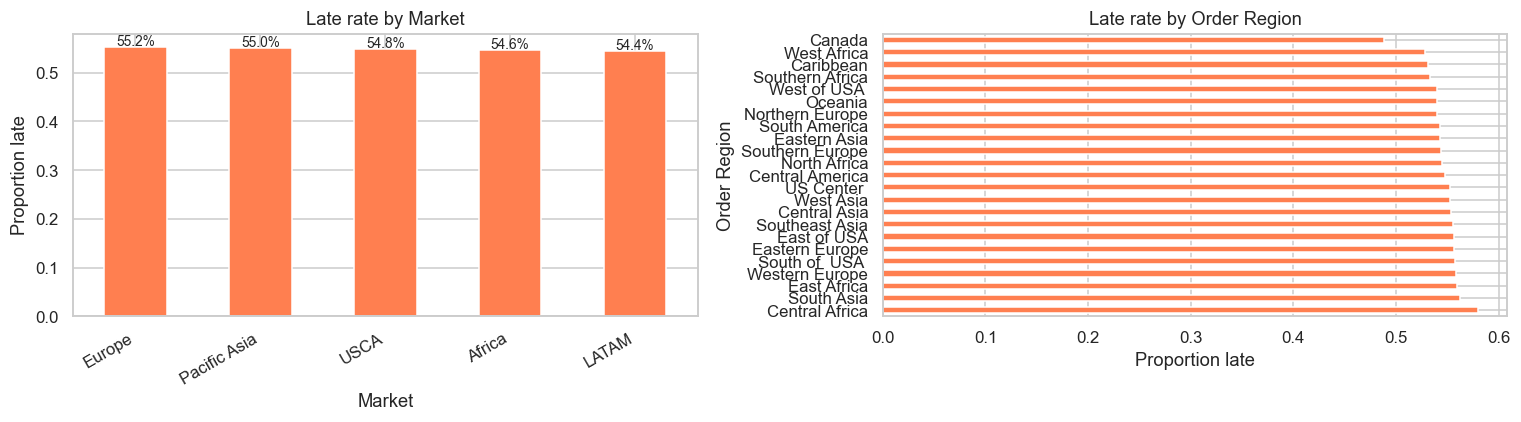

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

late_by_market = df.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False)
late_by_market.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Late rate by Market')
axes[0].set_ylabel('Proportion late')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
for i, v in enumerate(late_by_market):
    axes[0].text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)

late_by_region = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False)
late_by_region.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Late rate by Order Region')
axes[1].set_xlabel('Proportion late')

plt.tight_layout()
plt.show()

## 7. Customer Segment and Order Status

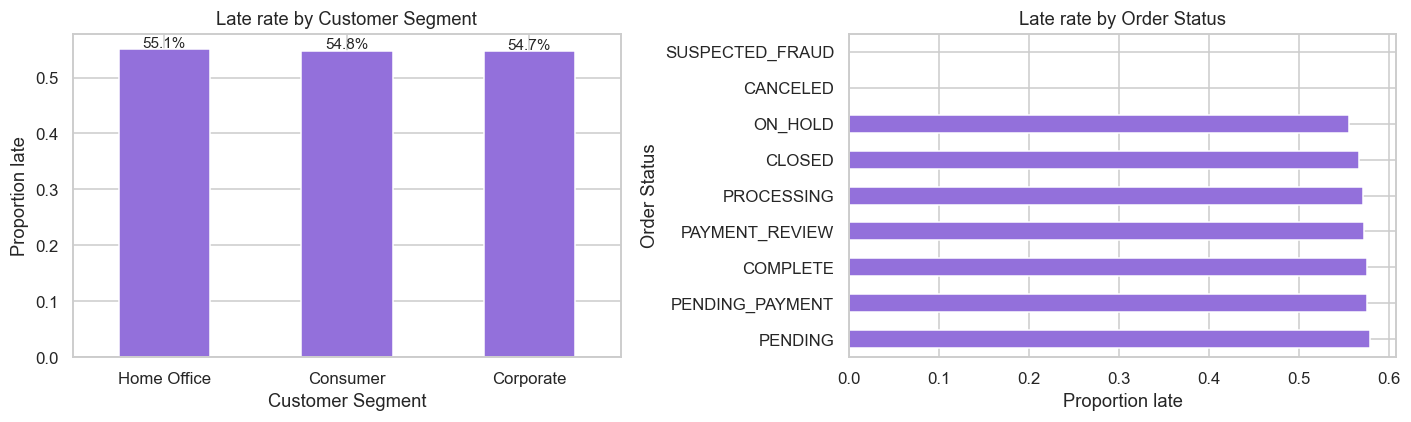

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

late_by_seg = df.groupby('Customer Segment')['Late_delivery_risk'].mean().sort_values(ascending=False)
late_by_seg.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Late rate by Customer Segment')
axes[0].set_ylabel('Proportion late')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(late_by_seg):
    axes[0].text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=10)

late_by_status = df.groupby('Order Status')['Late_delivery_risk'].mean().sort_values(ascending=False)
late_by_status.plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Late rate by Order Status')
axes[1].set_xlabel('Proportion late')

plt.tight_layout()
plt.show()

## 8. Numeric features — distributions and correlations with target

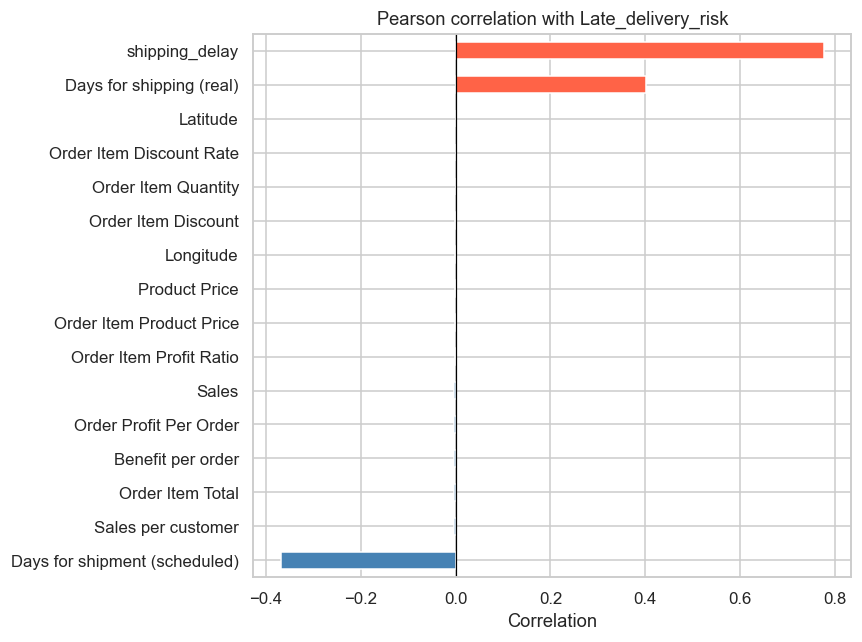

Top positive correlations (→ more likely late):
Order Item Quantity        -0.000
Order Item Discount Rate    0.000
Latitude                    0.001
Days for shipping (real)    0.401
shipping_delay              0.778
Name: Late_delivery_risk, dtype: float64

Top negative correlations (→ less likely late):
Days for shipment (scheduled)   -0.369
Sales per customer              -0.004
Order Item Total                -0.004
Benefit per order               -0.004
Order Profit Per Order          -0.004
Name: Late_delivery_risk, dtype: float64


In [10]:
num_cols = [
    'Days for shipping (real)', 'Days for shipment (scheduled)', 'shipping_delay',
    'Benefit per order', 'Sales per customer', 'Order Item Discount',
    'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio',
    'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order',
    'Product Price', 'Latitude', 'Longitude'
]

corr = df[num_cols + ['Late_delivery_risk']].corr()['Late_delivery_risk'].drop('Late_delivery_risk').sort_values()

plt.figure(figsize=(8, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr]
corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Pearson correlation with Late_delivery_risk')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

print("Top positive correlations (→ more likely late):")
print(corr.tail(5).round(3))
print("\nTop negative correlations (→ less likely late):")
print(corr.head(5).round(3))

## 9. Time patterns — order date

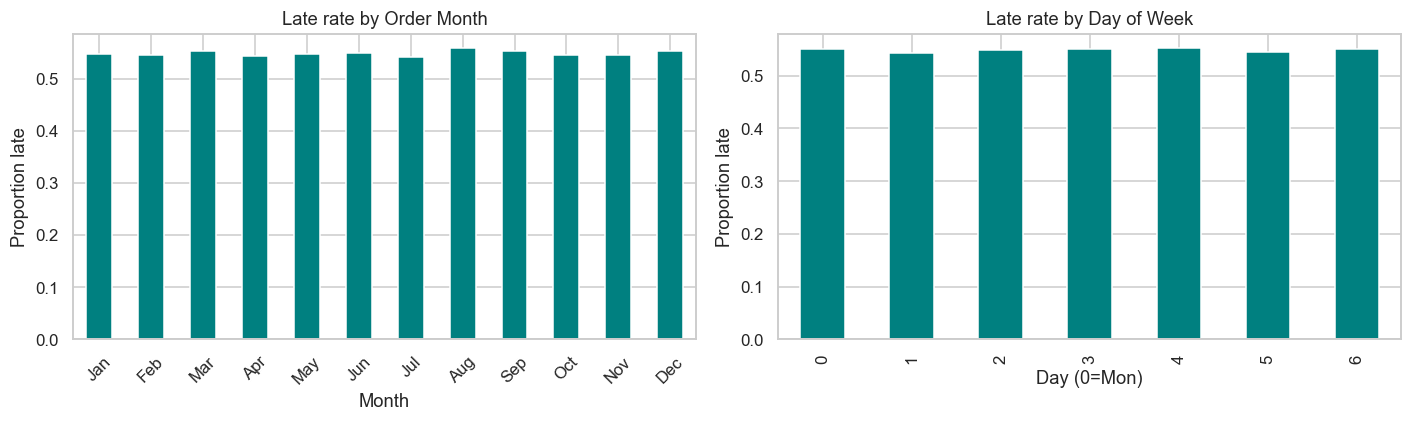

Month and day-of-week show modest variation — useful as features.


In [11]:
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_dow'] = df['order date (DateOrders)'].dt.dayofweek   # 0=Mon

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

late_by_month = df.groupby('order_month')['Late_delivery_risk'].mean()
late_by_month.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Late rate by Order Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Proportion late')
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

late_by_dow = df.groupby('order_dow')['Late_delivery_risk'].mean()
late_by_dow.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Late rate by Day of Week')
axes[1].set_xlabel('Day (0=Mon)')
axes[1].set_ylabel('Proportion late')

plt.tight_layout()
plt.show()
print("Month and day-of-week show modest variation — useful as features.")

## 10. Leakage audit — columns that must be excluded from modelling

In [12]:
print("""
LEAKAGE / UNUSABLE COLUMNS (must be dropped before modelling)
==============================================================
1. Delivery Status         — IS the target (maps 1:1 to Late_delivery_risk)
2. Days for shipping (real)— known only AFTER delivery; leaks the outcome
3. shipping_delay          — derived from (1) above; same leakage
4. shipping date (DateOrders) — known after shipment; leaks delivery timing
5. Order Zipcode           — 86% null; not useful
6. Product Description     — 100% null; empty column
7. Customer Email / Password / Fname / Lname — PII, not predictive
8. Product Image           — URL string, not predictive
9. Customer Street         — high-cardinality PII

POTENTIALLY LEAKY (evaluate carefully)
=======================================
- Days for shipment (scheduled) — this IS known at order time (it's the SLA), safe to use
- Order Status (COMPLETE, PENDING, etc.) — set after delivery for most statuses; use with care
  → Recommendation: drop Order Status too, or only use pre-shipment statuses
""")

# Confirm leakage in Delivery Status
print("Delivery Status vs Late_delivery_risk — perfect correlation?")
print(df.groupby(['Delivery Status', 'Late_delivery_risk']).size().unstack(fill_value=0))


LEAKAGE / UNUSABLE COLUMNS (must be dropped before modelling)
1. Delivery Status         — IS the target (maps 1:1 to Late_delivery_risk)
2. Days for shipping (real)— known only AFTER delivery; leaks the outcome
3. shipping_delay          — derived from (1) above; same leakage
4. shipping date (DateOrders) — known after shipment; leaks delivery timing
5. Order Zipcode           — 86% null; not useful
6. Product Description     — 100% null; empty column
7. Customer Email / Password / Fname / Lname — PII, not predictive
8. Product Image           — URL string, not predictive
9. Customer Street         — high-cardinality PII

POTENTIALLY LEAKY (evaluate carefully)
- Days for shipment (scheduled) — this IS known at order time (it's the SLA), safe to use
- Order Status (COMPLETE, PENDING, etc.) — set after delivery for most statuses; use with care
  → Recommendation: drop Order Status too, or only use pre-shipment statuses

Delivery Status vs Late_delivery_risk — perfect correlation?
Late_

## 11. Category and Department analysis

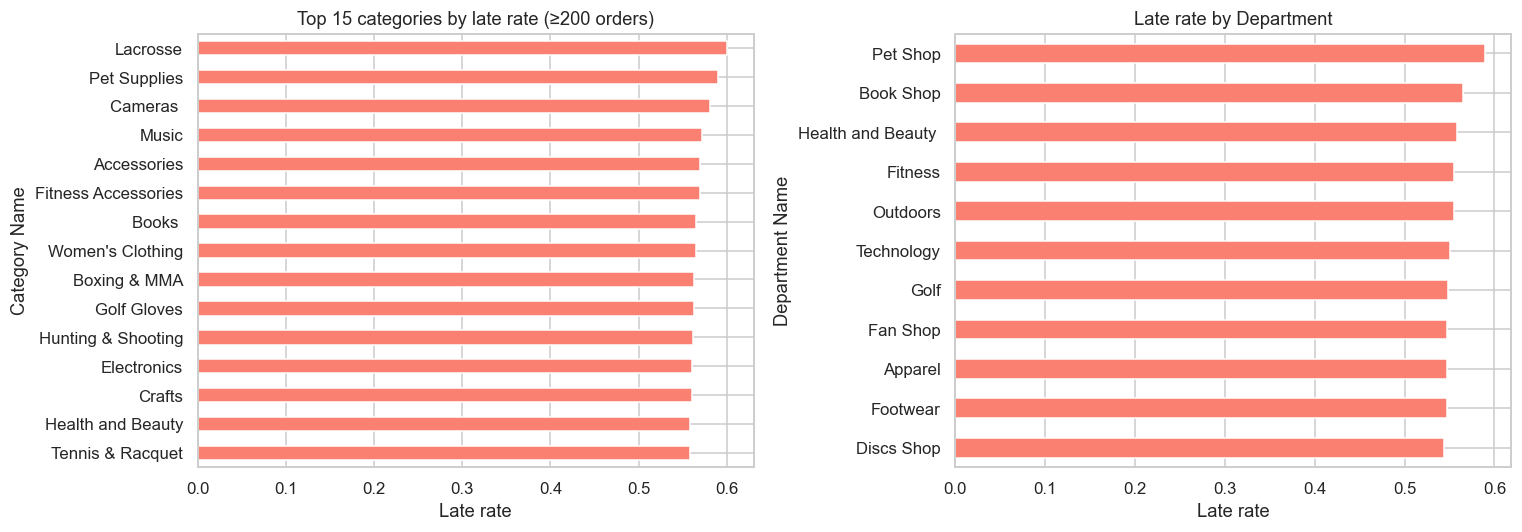

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 categories by late rate (min 200 orders)
cat_stats = df.groupby('Category Name').agg(
    late_rate=('Late_delivery_risk', 'mean'),
    count=('Late_delivery_risk', 'count')
).query('count >= 200').sort_values('late_rate', ascending=True).tail(15)

cat_stats['late_rate'].plot(kind='barh', ax=axes[0], color='salmon', edgecolor='white')
axes[0].set_title('Top 15 categories by late rate (≥200 orders)')
axes[0].set_xlabel('Late rate')

# Department
late_by_dept = df.groupby('Department Name')['Late_delivery_risk'].mean().sort_values()
late_by_dept.plot(kind='barh', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Late rate by Department')
axes[1].set_xlabel('Late rate')

plt.tight_layout()
plt.show()

## 12. Numeric feature correlation heatmap

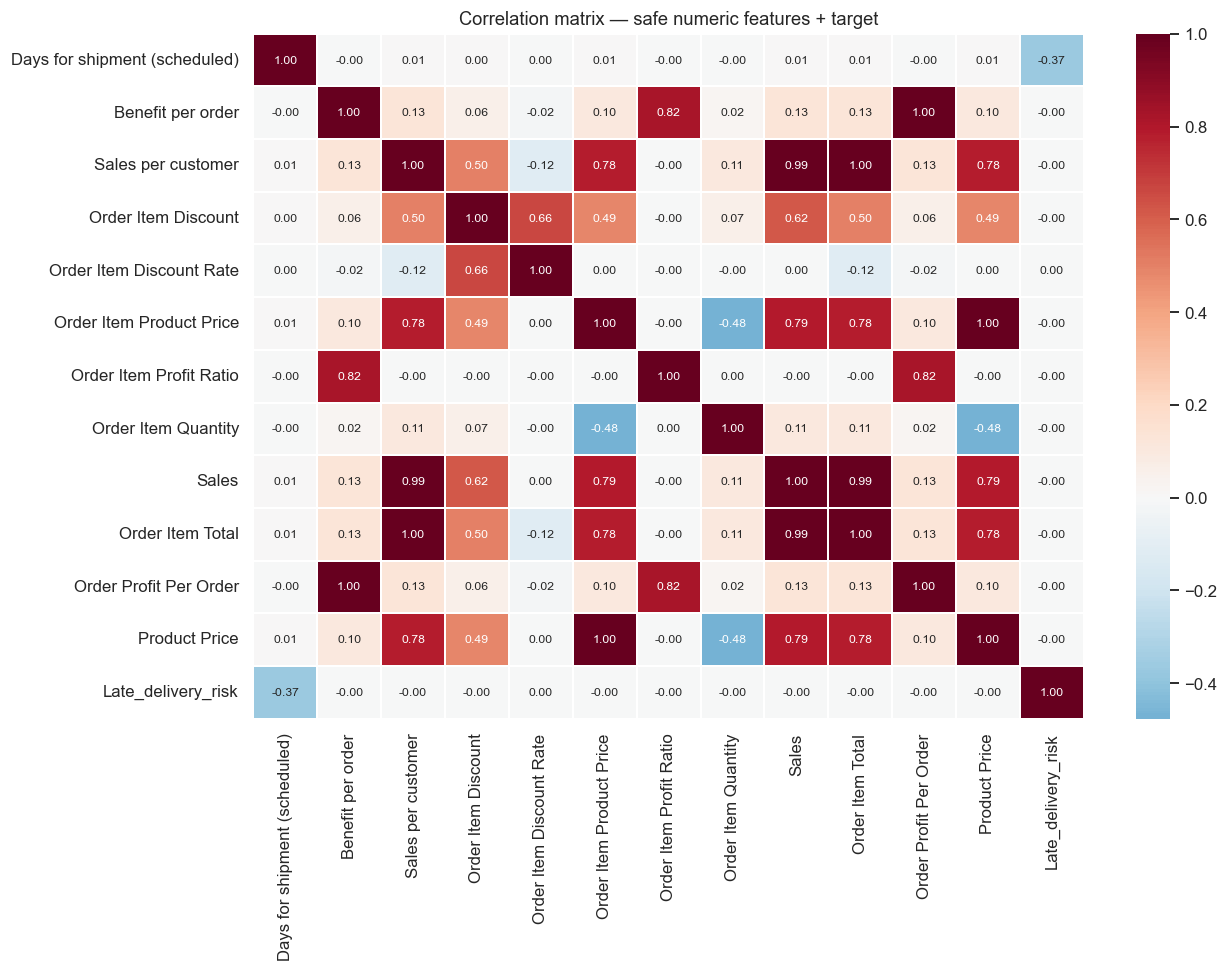

In [14]:
safe_num_cols = [
    'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer',
    'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price',
    'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
    'Order Item Total', 'Order Profit Per Order', 'Product Price',
    'Late_delivery_risk'
]

plt.figure(figsize=(12, 9))
sns.heatmap(df[safe_num_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.3, annot_kws={'size': 8})
plt.title('Correlation matrix — safe numeric features + target')
plt.tight_layout()
plt.show()

## 13. EDA Summary & Phase 2 feature plan

In [15]:
summary = """
╔══════════════════════════════════════════════════════════════════════════╗
║              PHASE 1 EDA — KEY FINDINGS                                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Dataset      180,519 rows × 53 columns                                 ║
║  Target       Late_delivery_risk  (binary: 1=late, 0=on-time/early)     ║
║  Class split  54.8% late, 45.2% on-time — mild imbalance, manageable    ║
╠══════════════════════════════════════════════════════════════════════════╣
║  DATA QUALITY                                                           ║
║  • Product Description  100% null → drop                                ║
║  • Order Zipcode         86% null → drop                                ║
║  • Everything else       <0.01% null → fine                             ║
╠══════════════════════════════════════════════════════════════════════════╣
║  TOP SIGNALS (safe from leakage)                                        ║
║  1. Shipping Mode       — Standard Class: ~70% late; Same Day: ~1%      ║
║  2. Days for shipment (scheduled) — SLA days known at order time        ║
║  3. Market / Order Region — geographic variance in late rates           ║
║  4. Customer Segment    — modest variation (~1-2% between segments)     ║
║  5. Category / Department — some categories significantly higher risk   ║
║  6. Order month / day-of-week — seasonal / weekly patterns              ║
║  7. Numeric order features — weak but nonzero correlations              ║
╠══════════════════════════════════════════════════════════════════════════╣
║  LEAKAGE — MUST EXCLUDE                                                 ║
║  • Delivery Status (is the target)                                      ║
║  • Days for shipping (real) (post-delivery)                             ║
║  • shipping date (post-delivery)                                        ║
║  • Order Status (mostly set after delivery)                             ║
╠══════════════════════════════════════════════════════════════════════════╣
║  PHASE 2 PLAN                                                           ║
║  Feature engineering:                                                   ║
║    - Encode Shipping Mode, Market, Region, Segment, Category, Dept      ║
║    - Extract order_month, order_dow from order date                     ║
║    - Keep Days for shipment (scheduled)                                 ║
║    - Drop leaky + useless columns                                       ║
║  Models to try:                                                         ║
║    - Logistic Regression (baseline)                                     ║
║    - Random Forest                                                      ║
║    - XGBoost (likely best given categorical + numeric mix)              ║
║  Metric: ROC-AUC + F1 (mild imbalance; both matter)                    ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════════╗
║              PHASE 1 EDA — KEY FINDINGS                                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Dataset      180,519 rows × 53 columns                                 ║
║  Target       Late_delivery_risk  (binary: 1=late, 0=on-time/early)     ║
║  Class split  54.8% late, 45.2% on-time — mild imbalance, manageable    ║
╠══════════════════════════════════════════════════════════════════════════╣
║  DATA QUALITY                                                           ║
║  • Product Description  100% null → drop                                ║
║  • Order Zipcode         86% null → drop                                ║
║  • Everything else       <0.01% null → fine                             ║
╠══════════════════════════════════════════════════════════════════════════╣
║  TOP SIGNALS (safe from leakage)                                        ║
║  1. S